In [12]:
!pip install kaggle -q
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ruchi798/housing-prices-in-metropolitan-areas-of-india
!unzip -q housing-prices-in-metropolitan-areas-of-india.zip -d /content/data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ruchi798/housing-prices-in-metropolitan-areas-of-india
License(s): CC0-1.0
housing-prices-in-metropolitan-areas-of-india.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/data/Bangalore.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/Chennai.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/data/Chennai.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [13]:
import pandas as pd
import numpy as np
import glob
import os

csv_files = glob.glob("/content/data/**/*.csv", recursive=True)

dfs = []
for f in csv_files:
    city_name = os.path.splitext(os.path.basename(f))[0]
    d = pd.read_csv(f)
    d["City"] = city_name
    dfs.append(d)
    print(f"{city_name}: {d.shape}, columns: {list(d.columns)[:8]}...")

combined = pd.concat(dfs, ignore_index=True, sort=False)
print("\nCombined shape:", combined.shape)
print("\nRows per city:")
print(combined["City"].value_counts())
print("\nAll columns:", list(combined.columns))

Kolkata: (6507, 41), columns: ['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool']...
Bangalore: (6207, 41), columns: ['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool']...
Chennai: (5014, 41), columns: ['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool']...
Delhi: (4998, 41), columns: ['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool']...
Mumbai: (7719, 41), columns: ['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool']...
Hyderabad: (2518, 41), columns: ['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool']...

Combined shape: (32963, 41)

Rows per city:
City
Mumbai       7719
Kolkata      6507
Bangalore    6207
Chennai      5014
Delhi        4998
Hyderabad    

              Price          Area  No. of Bedrooms        Resale  \
count  3.296300e+04  32963.000000     32963.000000  32963.000000   
mean   1.168672e+07   1293.362194         2.411765      0.381397   
std    2.307368e+07    763.703754         0.812800      0.485737   
min    2.000000e+06    200.000000         1.000000      0.000000   
25%    4.071500e+06    853.000000         2.000000      0.000000   
50%    6.711000e+06   1125.000000         2.000000      0.000000   
75%    1.200000e+07   1500.000000         3.000000      1.000000   
max    8.546000e+08  16000.000000         9.000000      1.000000   

       MaintenanceStaff     Gymnasium  SwimmingPool  LandscapedGardens  \
count      32963.000000  32963.000000  32963.000000       32963.000000   
mean           6.296454      6.403725      6.371325           6.351151   
std            4.075024      3.917995      3.966385           3.996086   
min            0.000000      0.000000      0.000000           0.000000   
25%            0.

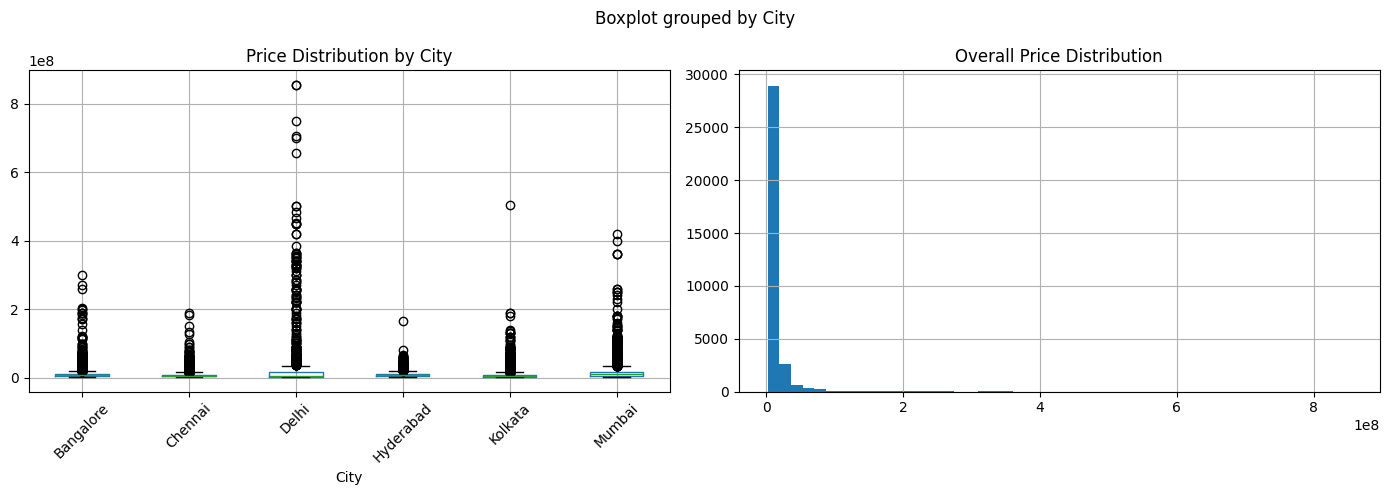

In [14]:
print(combined.describe())
print("\nMissing values per column:")
print(combined.isnull().sum()[combined.isnull().sum() > 0])

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
combined.boxplot(column="Price", by="City", ax=axes[0], rot=45)
axes[0].set_title("Price Distribution by City")
combined["Price"].hist(bins=50, ax=axes[1])
axes[1].set_title("Overall Price Distribution")
plt.tight_layout()
plt.show()

In [15]:
essential_cols = ["Price", "Area"]

combined = combined.dropna(subset=essential_cols)

amenity_cols = [c for c in combined.columns if c not in essential_cols + ["City"]]
combined[amenity_cols] = combined[amenity_cols].fillna(0)

print("Shape after dropping rows missing Price/Area:", combined.shape)

Shape after dropping rows missing Price/Area: (32963, 41)


In [16]:
combined["price_per_sqft"] = combined["Price"] / combined["Area"]

print(combined["price_per_sqft"].describe())

Q1 = combined["price_per_sqft"].quantile(0.25)
Q3 = combined["price_per_sqft"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(combined)
combined = combined[(combined["price_per_sqft"] >= lower_bound) & (combined["price_per_sqft"] <= upper_bound)]
after = len(combined)
print(f"Removed {before - after} outlier rows ({(before-after)/before:.1%})")

count    3.296300e+04
mean     9.746699e+03
std      1.823321e+04
min      2.410000e+02
25%      4.000000e+03
50%      5.775556e+03
75%      9.500000e+03
max      1.076444e+06
Name: price_per_sqft, dtype: float64
Removed 3420 outlier rows (10.4%)


Price skewness: 4.145701116182031
log(Price) skewness: 0.49620775790622645


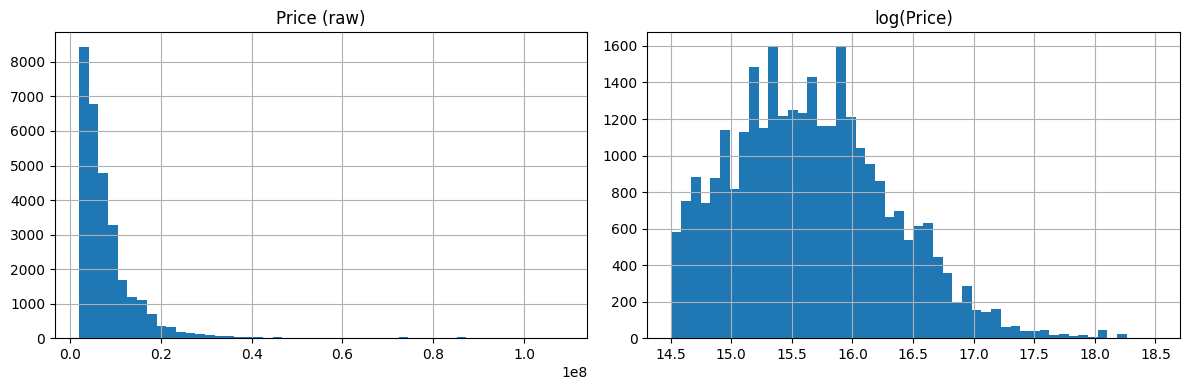

In [17]:
from scipy.stats import skew

print("Price skewness:", skew(combined["Price"]))
print("log(Price) skewness:", skew(np.log1p(combined["Price"])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
combined["Price"].hist(bins=50, ax=axes[0])
axes[0].set_title("Price (raw)")
np.log1p(combined["Price"]).hist(bins=50, ax=axes[1])
axes[1].set_title("log(Price)")
plt.tight_layout()
plt.show()

combined["log_price"] = np.log1p(combined["Price"])

In [18]:
combined = pd.get_dummies(combined, columns=["City"], drop_first=True)

feature_cols = [c for c in combined.columns if c not in ["Price", "log_price", "price_per_sqft"]]
print(f"Final feature count: {len(feature_cols)}")
print(feature_cols)

X = combined[feature_cols]
y = combined["log_price"]

Final feature count: 44
['Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens', 'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall', 'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School', '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter', 'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine', 'Gasconnection', 'AC', 'Wifi', "Children'splayarea", 'LiftAvailable', 'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV', 'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai']


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# One-hot encode the 'Location' column
combined = pd.get_dummies(combined, columns=["Location"], drop_first=True)

feature_cols = [c for c in combined.columns if c not in ["Price", "log_price", "price_per_sqft"]]
print(f"Final feature count: {len(feature_cols)}")
print(feature_cols)

X = combined[feature_cols]
y = combined["log_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}
def evaluate(name, y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    results[name] = {
        "R2 (log scale)": r2_score(y_true_log, y_pred_log),
        "RMSE (rupees)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE (rupees)": mean_absolute_error(y_true, y_pred)
    }

Final feature count: 1687
['Area', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens', 'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall', 'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School', '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter', 'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine', 'Gasconnection', 'AC', 'Wifi', "Children'splayarea", 'LiftAvailable', 'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV', 'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai', 'Location_200 Feet Radial Road', 'Location_3 Dwarka Sector 9 Road', 'Location_47 Sector 22 Road', 'Location_48 Sector 22 Road', 'Location_59 Sector 22 Road', 'Location_5th Phase', 'Location_5th Stage BEML Layout', 'Location_5th Stage Raja Rajeshwari Nagar', 'Location_6th phase jp nagar', 'Location_72 Sector 23 Road', 'Location_75 Noida Road', 'Locatio

In [21]:
lr = LinearRegression().fit(X_train_scaled, y_train)
evaluate("Linear Regression", y_test, lr.predict(X_test_scaled))

ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
evaluate("Ridge", y_test, ridge.predict(X_test_scaled))

lasso = Lasso(alpha=0.001).fit(X_train_scaled, y_train)
evaluate("Lasso", y_test, lasso.predict(X_test_scaled))

rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1).fit(X_train, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test))

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42).fit(X_train, y_train)
evaluate("XGBoost", y_test, xgb_model.predict(X_test))

results_df = pd.DataFrame(results).T
print(results_df.round(4))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.202e+00, tolerance: 1.015e+00
  model = cd_fast.enet_coordinate_descent(


                   R2 (log scale)  RMSE (rupees)  MAE (rupees)
Linear Regression          0.4214   5.726966e+06  3.011235e+06
Ridge                      0.4370   5.636641e+06  2.972481e+06
Lasso                      0.4604   5.717279e+06  2.962981e+06
Random Forest              0.5313   4.888299e+06  2.638484e+06
XGBoost                    0.5228   5.085500e+06  2.740663e+06


Top 15 Random Forest features:
Area                    0.591770
City_Delhi              0.050515
City_Mumbai             0.049246
City_Kolkata            0.043833
Location_Noida          0.019096
No. of Bedrooms         0.012497
Location_Alipore        0.010525
Resale                  0.010328
MaintenanceStaff        0.006919
City_Chennai            0.006063
Gasconnection           0.005522
LiftAvailable           0.005112
Location_Nala Sopara    0.005036
Location_Vasant Kunj    0.004711
City_Hyderabad          0.004567
dtype: float64

Top 15 XGBoost features:
City_Delhi              0.056770
City_Kolkata            0.046925
City_Mumbai             0.038328
Location_Alipore        0.038211
Location_Noida          0.025391
DiningTable             0.023493
School                  0.023299
Area                    0.020214
Sofa                    0.019548
MaintenanceStaff        0.017637
City_Chennai            0.012103
Location_Nala Sopara    0.012100
Wifi                    0.011756
City

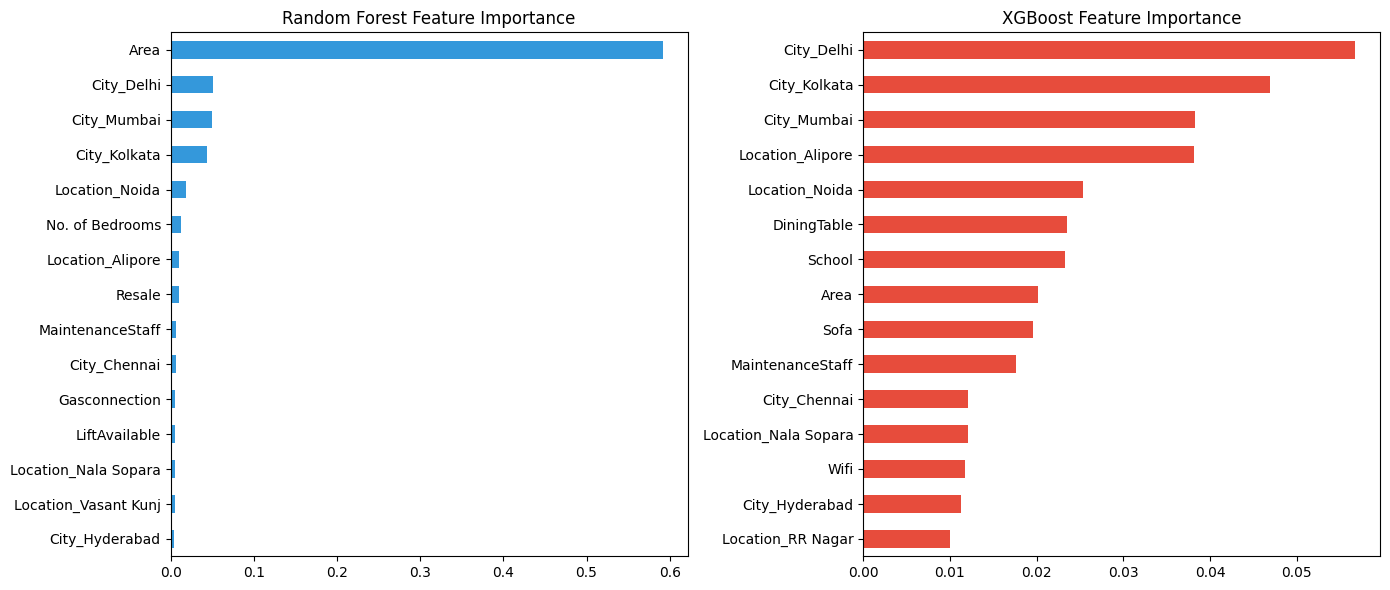

In [22]:
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 15 Random Forest features:")
print(rf_importance.head(15))

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 15 XGBoost features:")
print(xgb_importance.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.head(15).sort_values().plot(kind="barh", ax=axes[0], color="#3498db")
axes[0].set_title("Random Forest Feature Importance")
xgb_importance.head(15).sort_values().plot(kind="barh", ax=axes[1], color="#e74c3c")
axes[1].set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [23]:
import pickle
import json

final_scaler = StandardScaler().fit(X)
best_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
best_model.fit(X, y)  # swap for Linear/Ridge/Lasso + scaled X if one of those won instead

with open("house_price_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(final_scaler, f)

feature_info = {
    "feature_names": feature_cols,
    "feature_stats": X.describe().to_dict(),
    "cities": [c.replace("City_", "") for c in feature_cols if c.startswith("City_")]
}
with open("feature_info.json", "w") as f:
    json.dump(feature_info, f, default=str)

print("Saved: house_price_model.pkl, scaler.pkl, feature_info.json")

from google.colab import files
files.download("house_price_model.pkl")
files.download("scaler.pkl")
files.download("feature_info.json")

Saved: house_price_model.pkl, scaler.pkl, feature_info.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>